# AFL Data Foundations — EDA, Feature Engineering & Prediction Targets

**Dataset:** four AFL CSV tables supplied with the assignment  
**Feature-table version:** `v1`  
**Prediction philosophy:** leakage-safe, time-aware sports forecasting.

This notebook documents the data grain and joins, defines match and top-player targets, performs EDA, creates pre-match rolling/contextual features, and applies a strict time-based train/hold-out split.

## Task 1 — Data Inventory & Understanding

### Table grains
- `afl_players_info_raw.csv`: one row per player profile.
- `afl_players_round_by_round_stats_raw.csv`: one row per player-game.
- `afl_players_seasonal_stats_raw.csv`: one row per player-season/phase (`is_finals` distinguishes finals from non-finals).
- `team_matches_home_away_raw.csv`: two rows per match, one from each team's perspective.

### Join strategy
- Player tables join through `player_id`.
- Team match records are joined conceptually through team/opponent/date/round; because historical team names are inconsistent, this notebook normalizes whitespace and `W. Bulldogs -> Western Bulldogs`.
- For match modeling, the home row is used as the single match anchor, so there are exactly two team-perspective rows per match in the source.


In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_DIR = Path("data")

def load_first(prefix):
    files = list(DATA_DIR.glob(prefix + "*.csv"))
    if not files:
        raise FileNotFoundError(f"No file matching {prefix}*.csv in {DATA_DIR.resolve()}")
    return pd.read_csv(files[0], low_memory=False)

players_info = load_first("afl_players_info_raw")
player_round = load_first("afl_players_round_by_round_stats_raw")
player_season = load_first("afl_players_seasonal_stats_raw")
team_matches = load_first("team_matches_home_away_raw")

print("Loaded tables:")
for name, df in [
    ("players_info", players_info),
    ("player_round", player_round),
    ("player_season", player_season),
    ("team_matches", team_matches),
]:
    print(f"- {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded tables:
- players_info: 2,848 rows x 16 columns
- player_round: 274,089 rows x 36 columns
- player_season: 25,491 rows x 54 columns
- team_matches: 15,808 rows x 19 columns


In [2]:
# Coverage and quality checks
team_matches["match_date"] = pd.to_datetime(team_matches["match_date"], errors="coerce")
player_round["match_date"] = pd.to_datetime(player_round["match_date"], errors="coerce")

print("Team-match coverage:", team_matches["match_date"].min().date(), "to", team_matches["match_date"].max().date())
print("Seasons:", team_matches["year"].min(), "to", team_matches["year"].max(), "(", team_matches["year"].nunique(), "seasons )")
print("Raw team names:", team_matches["team_name"].nunique())
print("Players in player-game table:", player_round["player_id"].nunique())

print("\nDuplicate IDs:")
print("team_matches.id:", team_matches["id"].duplicated().sum())
print("player_round.id:", player_round["id"].duplicated().sum())

print("\nHighest missingness:")
for name, df in [("players_info", players_info), ("player_round", player_round),
                 ("player_season", player_season), ("team_matches", team_matches)]:
    miss = (df.isna().mean()*100).sort_values(ascending=False).head(8).round(1)
    print("\n", name)
    print(miss.to_string())


Team-match coverage: 1983-03-26 to 2025-09-27
Seasons: 1983 to 2025 ( 43 seasons )
Raw team names: 40
Players in player-game table: 3109

Duplicate IDs:
team_matches.id: 0
player_round.id: 10

Highest missingness:

 players_info
player_common_names    97.4
profile_pic            77.6
player_teams            3.3
id                      0.0
last_name               0.0
player_name             0.0
player_full_name        0.0
first_name              0.0

 player_round
score              100.0
brownlow_votes      40.3
goal_assist         37.8
bounces             35.5
hit_outs            35.3
marks_inside_50     33.3
contested_marks     33.1
behinds             29.6

 player_season
avg_goal_assists           27.8
goal_assists               27.8
brownlow_votes             27.4
avg_percentage_played      24.5
total_percentage_played    24.5
hit_outs                   22.4
avg_hit_outs               22.4
avg_bounces                22.2

 team_matches
crowd                  2.5
team_name         

### Structural changes / naming notes

The supplied data spans 1983–2025. The file contains historical team structures including Brisbane Bears/Fitzroy Lions in earlier seasons and Gold Coast Suns/Greater Western Sydney Giants from the expansion era. The same club can also appear with formatting/alias differences; the main explicit alias normalized here is `W. Bulldogs` to `Western Bulldogs`. Rule changes are not encoded as a dedicated field, so no rule-change effect is assumed in the model.

## Task 2 — Prediction Targets Precisely

### Match target contract
**Primary target:** `target_home_win` — binary classification, 1 when the home team wins and 0 otherwise.  
**Secondary target:** `target_margin` — regression target, home score minus away score.  
**Draw:** retained separately as `target_draw` and `target_result`. For a first classifier, draws are not silently relabeled as wins; the notebook keeps the original W/L/D information.

### Top-player target contract
1. **Top disposal-getter:** player with the maximum `disposals` in a match.
2. **Top goal-kicker:** player with the maximum `goals` in a match.
3. **Top fantasy player:** player with the maximum `fantasy_points` in a match.

Ties are resolved deterministically by the lowest `player_id`. These are post-match targets suitable for evaluating a pre-match player-ranking model.

**Important limitation:** no reliable player-position field is present in the supplied tables, so forward/midfielder/defender comparisons are not fabricated. Position analysis requires an additional position/lineage table.


### Data dictionary — target fields

| Target | Definition | Formula | Level |
|---|---|---|---|
| `target_home_win` | Home-team win indicator | `1(result == W)` | Match |
| `target_draw` | Draw indicator | `1(result == D)` | Match |
| `target_margin` | Home score margin | `home_score - away_score` | Match |
| `top_disposal_player_id` | Player with most disposals | `argmax(disposals)` | Player-in-match |
| `top_goal_kicker_player_id` | Player with most goals | `argmax(goals)` | Player-in-match |
| `top_fantasy_player_id` | Player with most fantasy points | `argmax(fantasy_points)` | Player-in-match |


In [3]:
# Normalize team names and anchor one row per match on the home team.
team_matches["team_name_norm"] = team_matches["team_name"].astype(str).str.strip().replace({"W. Bulldogs":"Western Bulldogs"})
team_matches["opponent_norm"] = team_matches["opponent"].astype(str).str.strip().replace({"W. Bulldogs":"Western Bulldogs"})
matches = team_matches.loc[team_matches["home_away"].eq("H")].copy()
matches = matches.sort_values(["match_date", "id"]).reset_index(drop=True)

print("Match rows:", len(matches))
print("Result counts from home-team perspective:")
print(matches["result"].value_counts())
print("Overall home-win rate:", round((matches["result"]=="W").mean(), 3))


Match rows: 7904
Result counts from home-team perspective:
result
W    4669
L    3170
D      65
Name: count, dtype: int64
Overall home-win rate: 0.591


## Task 3 — Exploratory Data Analysis

The following plots cover:
1. home-ground advantage over time,
2. recent form vs. home win rate,
3. rest advantage vs. scoring margin,
4. prior ladder strength vs. home win rate,
5. prior head-to-head record vs. home win rate,
6. player fantasy-point distribution.

Weather and travel distance are not present in the supplied tables, so they are not invented. A travel/interstate feature can be added later if venue/team-location data becomes available.


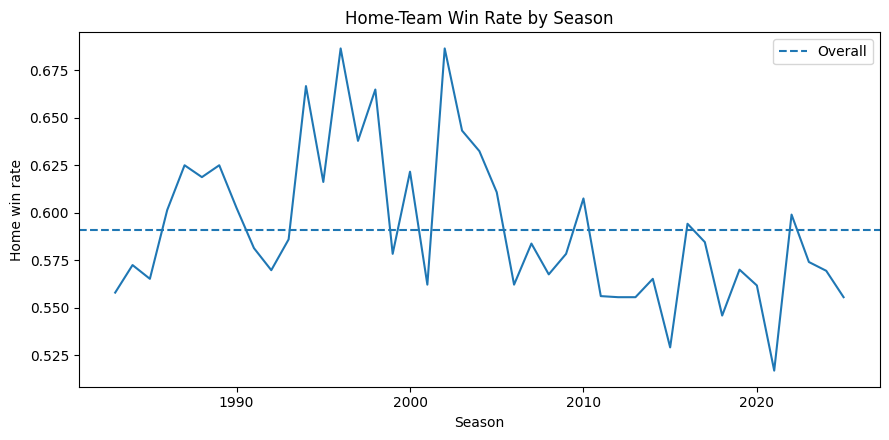

In [4]:
# Plot 1 — Home win rate by season
season_home = matches.groupby("year")["result"].apply(lambda s: (s=="W").mean())
plt.figure(figsize=(9,4.5))
plt.plot(season_home.index, season_home.values)
plt.axhline((matches["result"]=="W").mean(), linestyle="--", label="Overall")
plt.title("Home-Team Win Rate by Season")
plt.xlabel("Season"); plt.ylabel("Home win rate"); plt.legend(); plt.tight_layout()
plt.show()


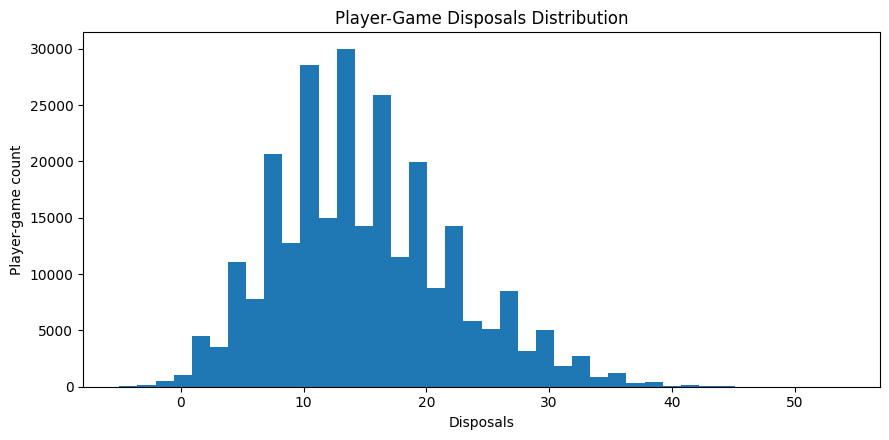

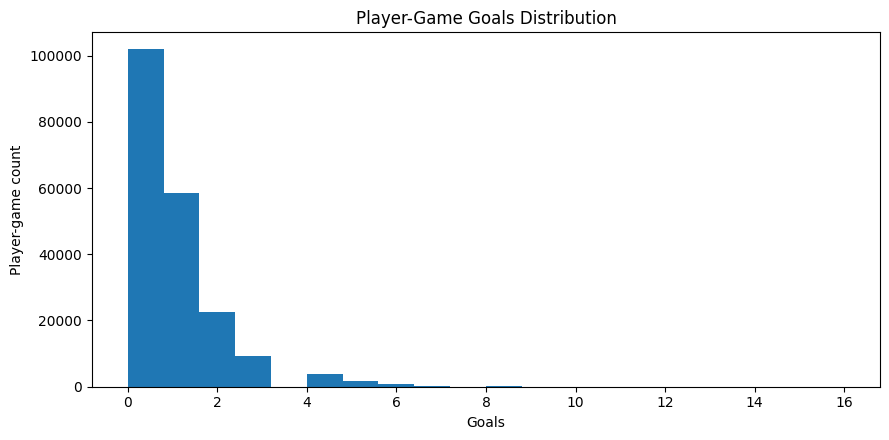

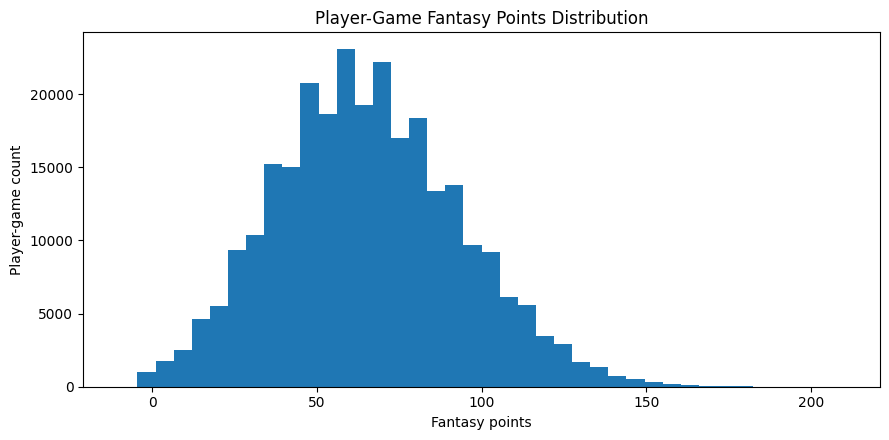

In [5]:
# Player distributions
pr = player_round.drop_duplicates(subset=["id"]).copy()
plt.figure(figsize=(9,4.5))
plt.hist(pr["disposals"].dropna(), bins=40)
plt.title("Player-Game Disposals Distribution")
plt.xlabel("Disposals"); plt.ylabel("Player-game count"); plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4.5))
plt.hist(pr["goals"].dropna(), bins=20)
plt.title("Player-Game Goals Distribution")
plt.xlabel("Goals"); plt.ylabel("Player-game count"); plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4.5))
plt.hist(pr["fantasy_points"].dropna(), bins=40)
plt.title("Player-Game Fantasy Points Distribution")
plt.xlabel("Fantasy points"); plt.ylabel("Player-game count"); plt.tight_layout()
plt.show()


## Task 4 — Feature Engineering

Every rolling/contextual feature below is computed from matches **strictly before** the current match:
- prior five-game win rate,
- prior five-game average points for/against,
- current win streak,
- days of rest,
- season-to-date ladder points and position,
- prior head-to-head record.

The current match's score/result is added to team histories **only after** its features are created. This is the key leakage-control rule.


In [6]:
def build_match_features(team_matches):
    data = team_matches.loc[team_matches["home_away"].eq("H")].copy()
    data = data.sort_values(["match_date", "id"]).reset_index(drop=True)

    history = defaultdict(list)
    last_date = {}
    season_stats = defaultdict(lambda: {"wins":0, "draws":0, "losses":0, "pf":0.0, "pa":0.0, "games":0})
    h2h = defaultdict(list)
    rows = []

    for _, r in data.iterrows():
        h, a = r["team_name_norm"], r["opponent_norm"]
        dt, yr = r["match_date"], int(r["year"])

        def recent(team):
            hist = history[team][-5:]
            wins = sum(x["result"]=="W" for x in hist)
            draws = sum(x["result"]=="D" for x in hist)
            return {
                "win_rate": (wins+0.5*draws)/len(hist) if hist else np.nan,
                "avg_for": np.mean([x["sf"] for x in hist]) if hist else np.nan,
                "avg_against": np.mean([x["sa"] for x in hist]) if hist else np.nan,
                "streak": next((i for i,x in enumerate(reversed(history[team])) if x["result"]!="W"), len(history[team])),
                "rest": (dt-last_date[team]).days if team in last_date else np.nan
            }

        fh, fa = recent(h), recent(a)

        def ladder(team):
            s = season_stats[(team,yr)]
            return 4*s["wins"] + 2*s["draws"]

        hp, ap = ladder(h), ladder(a)

        active = []
        for (team, season), s in season_stats.items():
            if season == yr and s["games"] > 0:
                pct = s["pf"]/s["pa"]*100 if s["pa"] else -np.inf
                active.append((team, 4*s["wins"]+2*s["draws"], pct))
        rank_map = {t:i+1 for i,(t,_,_) in enumerate(sorted(active, key=lambda x:(-x[1],-x[2],x[0])))}

        prior = h2h[tuple(sorted((h,a)))]
        h_wins = sum(w==h for w in prior)
        h_draws = sum(w=="DRAW" for w in prior)
        h2h_rate = (h_wins+0.5*h_draws)/len(prior) if prior else np.nan

        rows.append({
            "match_id": int(r["id"]), "match_date": dt, "season": yr, "round": str(r["round"]),
            "home_team": h, "away_team": a, "venue": str(r["venue"]).strip() if pd.notna(r["venue"]) else "Unknown",
            "home_score": r["team_score"], "away_score": r["opponent_score"],
            "target_home_win": int(r["result"]=="W"), "target_draw": int(r["result"]=="D"),
            "target_result": r["result"], "target_margin": r["team_score"]-r["opponent_score"],
            "home_win_rate_last5": fh["win_rate"], "away_win_rate_last5": fa["win_rate"],
            "home_avg_score_for_last5": fh["avg_for"], "away_avg_score_for_last5": fa["avg_for"],
            "home_avg_score_against_last5": fh["avg_against"], "away_avg_score_against_last5": fa["avg_against"],
            "home_win_streak": fh["streak"], "away_win_streak": fa["streak"],
            "home_rest_days": fh["rest"], "away_rest_days": fa["rest"],
            "home_ladder_points_prior": hp, "away_ladder_points_prior": ap,
            "home_ladder_position_prior": rank_map.get(h,np.nan), "away_ladder_position_prior": rank_map.get(a,np.nan),
            "ladder_points_diff": hp-ap, "h2h_home_win_rate_prior": h2h_rate,
            "h2h_games_prior": len(prior)
        })

        hr = r["result"]
        ar = "L" if hr=="W" else "W" if hr=="L" else "D"
        history[h].append({"result":hr,"sf":r["team_score"],"sa":r["opponent_score"]})
        history[a].append({"result":ar,"sf":r["opponent_score"],"sa":r["team_score"]})
        last_date[h] = last_date[a] = dt

        for team,sf,sa,res in [(h,r["team_score"],r["opponent_score"],hr),(a,r["opponent_score"],r["team_score"],ar)]:
            s = season_stats[(team,yr)]
            s["games"] += 1; s["pf"] += sf; s["pa"] += sa
            if res=="W": s["wins"] += 1
            elif res=="L": s["losses"] += 1
            else: s["draws"] += 1

        h2h[tuple(sorted((h,a)))].append("DRAW" if hr=="D" else h if hr=="W" else a)

    return pd.DataFrame(rows)

features = build_match_features(team_matches)
features.to_csv("afl_match_features_v1.csv", index=False)
print("Saved:", len(features), "matches and", len(features.columns), "columns.")
print("Leakage check: feature construction updates histories only after the current row is recorded.")


Saved: 7904 matches and 30 columns.
Leakage check: feature construction updates histories only after the current row is recorded.


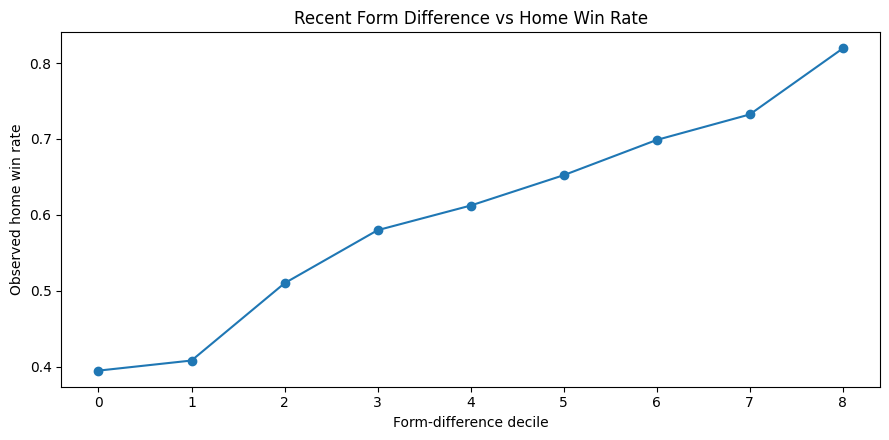

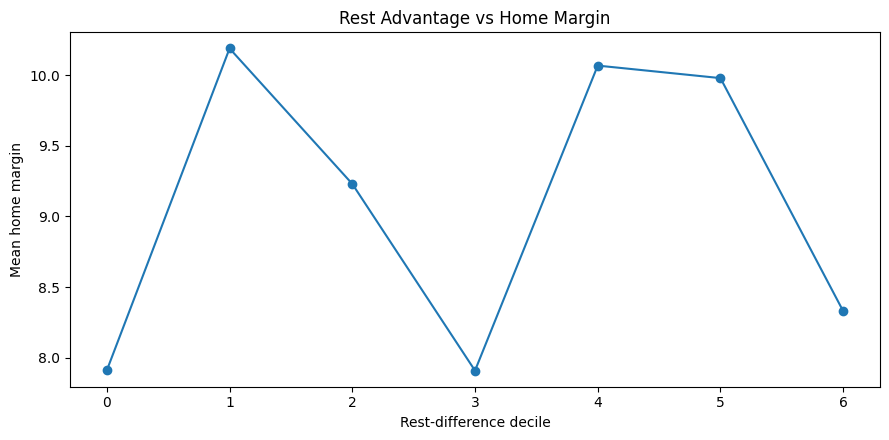

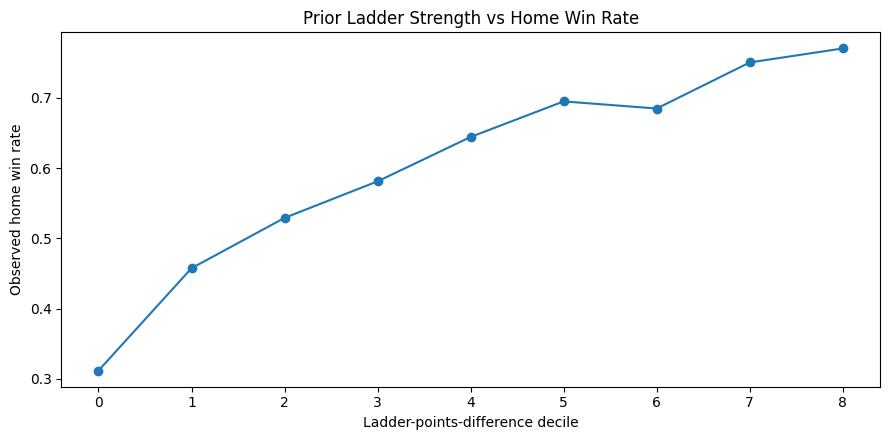

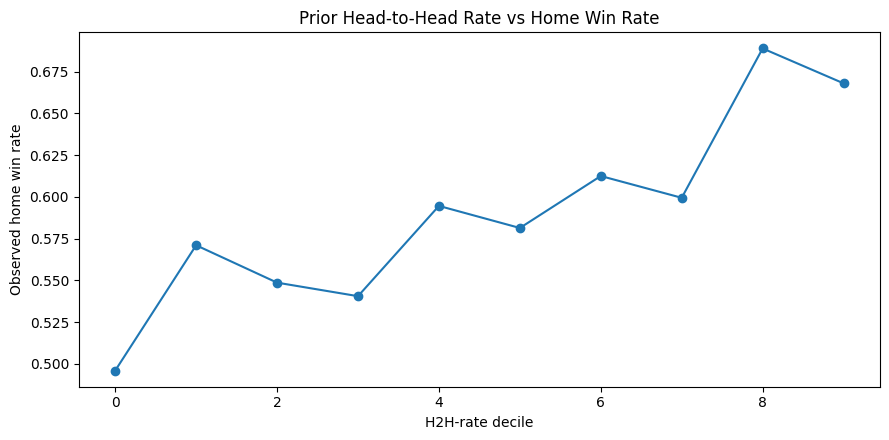

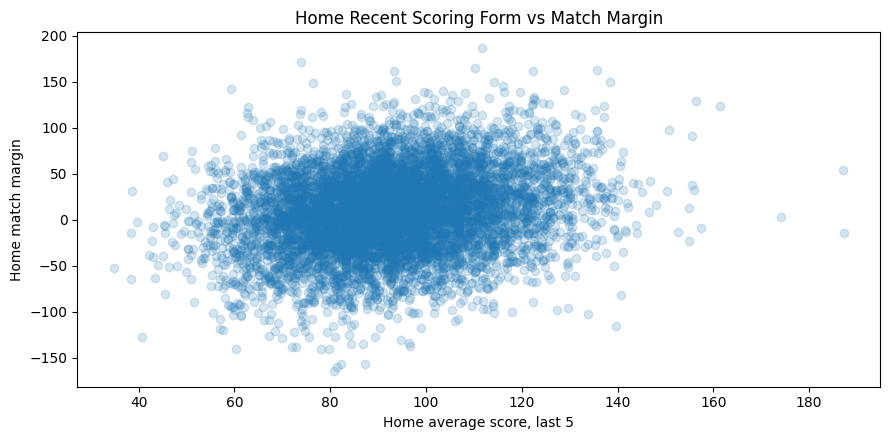

In [7]:
# Five prediction-relevant relationships from the engineered feature table.

f = features.dropna(subset=["home_win_rate_last5","away_win_rate_last5"]).copy()
f["form_diff"] = f["home_win_rate_last5"] - f["away_win_rate_last5"]
f["bin"] = pd.qcut(f["form_diff"], 10, duplicates="drop")
g = f.groupby("bin", observed=True)["target_home_win"].mean()
plt.figure(figsize=(9,4.5)); plt.plot(range(len(g)), g.values, marker="o")
plt.title("Recent Form Difference vs Home Win Rate"); plt.xlabel("Form-difference decile"); plt.ylabel("Observed home win rate"); plt.tight_layout(); plt.show()

f = features.dropna(subset=["home_rest_days","away_rest_days"]).copy()
f["rest_diff"] = f["home_rest_days"] - f["away_rest_days"]
f["bin"] = pd.qcut(f["rest_diff"], 10, duplicates="drop")
g = f.groupby("bin", observed=True)["target_margin"].mean()
plt.figure(figsize=(9,4.5)); plt.plot(range(len(g)), g.values, marker="o")
plt.title("Rest Advantage vs Home Margin"); plt.xlabel("Rest-difference decile"); plt.ylabel("Mean home margin"); plt.tight_layout(); plt.show()

f = features.dropna(subset=["ladder_points_diff"]).copy()
f["bin"] = pd.qcut(f["ladder_points_diff"], 10, duplicates="drop")
g = f.groupby("bin", observed=True)["target_home_win"].mean()
plt.figure(figsize=(9,4.5)); plt.plot(range(len(g)), g.values, marker="o")
plt.title("Prior Ladder Strength vs Home Win Rate"); plt.xlabel("Ladder-points-difference decile"); plt.ylabel("Observed home win rate"); plt.tight_layout(); plt.show()

f = features.dropna(subset=["h2h_home_win_rate_prior"]).copy()
f["bin"] = pd.qcut(f["h2h_home_win_rate_prior"], 10, duplicates="drop")
g = f.groupby("bin", observed=True)["target_home_win"].mean()
plt.figure(figsize=(9,4.5)); plt.plot(range(len(g)), g.values, marker="o")
plt.title("Prior Head-to-Head Rate vs Home Win Rate"); plt.xlabel("H2H-rate decile"); plt.ylabel("Observed home win rate"); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4.5))
plt.scatter(features["home_avg_score_for_last5"], features["target_margin"], alpha=0.18)
plt.title("Home Recent Scoring Form vs Match Margin")
plt.xlabel("Home average score, last 5"); plt.ylabel("Home match margin"); plt.tight_layout(); plt.show()


## Task 5 — Reproducible Train/Hold-Out Split

A random split is inappropriate because it can train on later matches and evaluate on earlier matches, allowing future-era information to influence the apparent score. The default split is **train = all seasons through 2024; hold-out = 2025**, representing a realistic future-season deployment test.

Perfect accuracy would be suspicious because AFL outcomes contain injuries, selection, form shocks, weather, tactics and other unobserved randomness. A model that is nearly perfect is more likely to be using post-match variables or another leakage path. The goal is therefore robust, repeatable out-of-time performance rather than a perfect score.


In [8]:
def time_split(df, holdout_season=None):
    df = df.sort_values(["match_date","match_id"]).reset_index(drop=True).copy()
    if holdout_season is None:
        holdout_season = int(df["season"].max())
    train = df[df["season"] < holdout_season].copy()
    holdout = df[df["season"] == holdout_season].copy()
    if train.empty or holdout.empty:
        raise ValueError("Time split produced an empty partition.")
    return train, holdout

train, holdout = time_split(features)

print("Train seasons:", train["season"].min(), "to", train["season"].max(), "| rows:", len(train))
print("Hold-out season:", holdout["season"].min(), "| rows:", len(holdout))
print("Train ends before hold-out starts:", train["match_date"].max() < holdout["match_date"].min())
print("Hold-out home-win rate:", round(holdout["target_home_win"].mean(), 3))


Train seasons: 1983 to 2024 | rows: 7688
Hold-out season: 2025 | rows: 216
Train ends before hold-out starts: True
Hold-out home-win rate: 0.556


## Versioning & reproducibility notes

- Feature table: `afl_match_features_v1.csv`
- Feature dictionary: `afl_feature_dictionary_v1.csv`
- Player target table: `afl_player_match_targets_v1.csv`
